In [1]:
# Hierarchical Clustering: dendrogram + cluster visualization
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import linkage, dendrogram

# ---
# 1) Load a real dataset (NOT blobs, NOT Iris)
# ---
data = load_wine()
X = data.data

# Standardize features (important for distance-based methods)
X_scaled = StandardScaler().fit_transform(X)

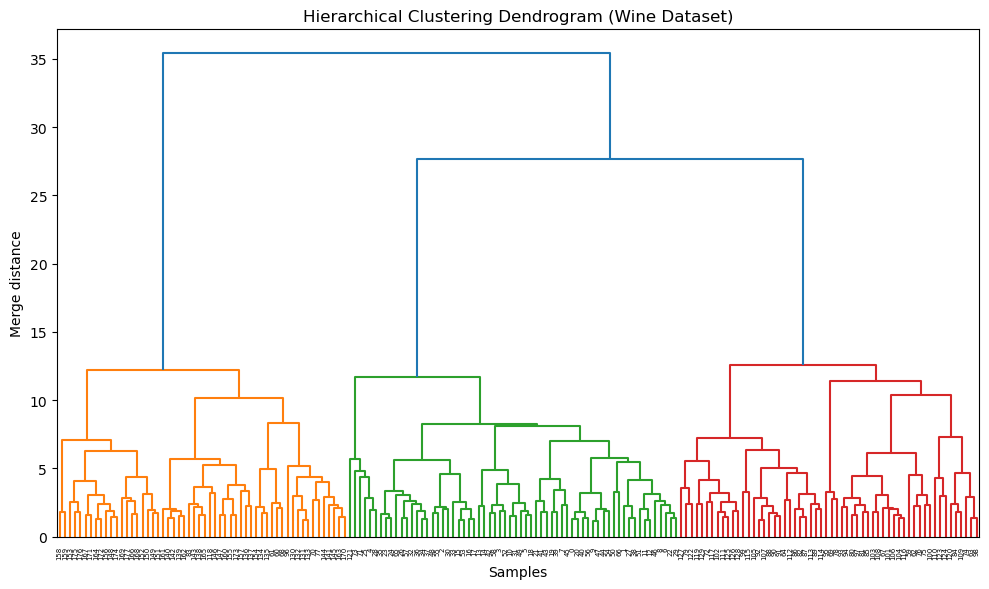

In [2]:
# ---
# 2) Compute Linkage matrix for dendrogram
# ---
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Wine Dataset)")
plt.xlabel("Samples")
plt.ylabel("Merge distance")
plt.tight_layout()
plt.show()

In [3]:
# ---
# 3) Fit hierarchical clustering model
# ---
n_clusters = 3    # chosen based on dendrogram inspection

hc = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward"
)

labels = hc.fit_predict(X_scaled)

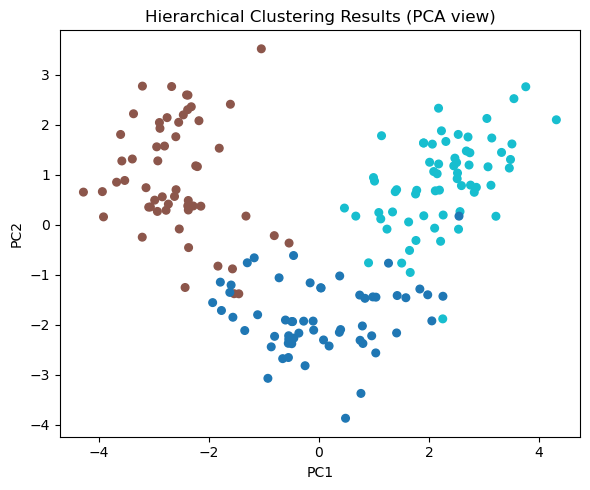

In [4]:
# ---
# 4) Reduce to 2D for visualization of clusters
# ---
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, cmap="tab10", s=30)
plt.title("Hierarchical Clustering Results (PCA view)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [5]:
print("Cluster counts:",np.bincount(labels))

Cluster counts: [58 56 64]
